In [ ]:
import pandas as pd
import  numpy as np
!pip install -q plotly kaleido
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
from math import pi
import matplotlib.pyplot as plt
BG, AX_BG = '#07071a', '#0d0d24'
TEXT_C = '#dde4f5'
PAL = ['#ff6b6b','#ffd93d','#6bcb77','#4d96ff','#c77dff',
       '#ff9f1c','#2ec4b6','#e63946','#a8dadc','#f4a261']
plt.rcParams.update({
    'figure.facecolor':BG,'axes.facecolor':AX_BG,'axes.edgecolor':'#1a1a3e',
    'axes.labelcolor':TEXT_C,'xtick.color':'#888','ytick.color':'#888',
    'text.color':TEXT_C,'grid.color':'#1a1a2e','grid.linestyle':'--',
    'font.family':'DejaVu Sans','axes.spines.top':False,'axes.spines.right':False,
})
PT = 'plotly_dark'
print('✅ Libraries loaded!')

✅ Libraries loaded!


In [ ]:
df=pd.read_csv('Consumer_Shopping_Trends_2026 (6).csv')
df.head(5)

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference
0,56,221111,6.5,12,0.7,1,6,16,16,28551,...,7,7,1,3,6,5,2,Other,Tier 3,Store
1,69,96029,8.2,13,2.7,6,9,14,1,124056,...,3,4,9,6,8,1,7,Male,Tier 3,Hybrid
2,46,19055,6.4,4,2.1,10,8,2,0,81939,...,4,10,1,1,3,3,3,Female,Tier 3,Store
3,32,53170,6.4,11,0.7,2,10,20,3,35901,...,10,2,4,8,2,6,6,Female,Tier 1,Store
4,60,244016,6.0,5,0.7,2,5,18,16,131971,...,2,5,8,9,7,1,6,Male,Tier 3,Store


In [ ]:
df['total_spend']      = df['avg_online_spend'] + df['avg_store_spend']
df['online_spend_pct'] = df['avg_online_spend'] / df['total_spend'].replace(0, np.nan) * 100
df['digital_score']    = (df['daily_internet_hours'] + df['social_media_hours'] +
                           df['tech_savvy_score'] + df['online_payment_trust_score']) / 4
df['age_group'] = pd.cut(df['age'], bins=[0,25,35,45,55,65,100],
                          labels=['18-25','26-35','36-45','46-55','56-65','65+'])
df['income_group'] = pd.cut(df['monthly_income'],
                             bins=[0,50000,100000,150000,200000,300000],
                             labels=['<50K','50-100K','100-150K','150-200K','200K+'])

print(f'\n✅ Loaded! Shape: {df.shape}')
print(f'Shopping preference: {df.shopping_preference.value_counts().to_dict()}')
print(f'City tiers         : {df.city_tier.value_counts().to_dict()}')
print(f'Gender split       : {df.gender.value_counts().to_dict()}')
df.head()


✅ Loaded! Shape: (11789, 30)
Shopping preference: {'Store': 10244, 'Online': 1176, 'Hybrid': 369}
City tiers         : {'Tier 1': 3982, 'Tier 3': 3949, 'Tier 2': 3858}
Gender split       : {'Male': 3966, 'Female': 3931, 'Other': 3892}


,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference,total_spend,online_spend_pct,digital_score,age_group,income_group
0,56,221111,6.5,12,0.7,1,6,16,16,28551,...,5,2,Other,Tier 3,Store,172643,16.537595,3.550,56-65,200K+
1,69,96029,8.2,13,2.7,6,9,14,1,124056,...,1,7,Male,Tier 3,Hybrid,152477,81.360467,6.475,65+,50-100K
2,46,19055,6.4,4,2.1,10,8,2,0,81939,...,3,3,Female,Tier 3,Store,210168,38.987382,6.625,46-55,<50K
3,32,53170,6.4,11,0.7,2,10,20,3,35901,...,6,6,Female,Tier 1,Store,170551,21.050009,4.775,26-35,50-100K
4,60,244016,6.0,5,0.7,2,5,18,16,131971,...,1,6,Male,Tier 3,Store,166093,79.456088,3.425,56-65,200K+


In [ ]:
kpi={
    'Total Consumers'      : f'{len(df):,}',
    'Avg Total Spend'      : f'₹{df.total_spend.mean():,.0f}',
    'Avg Online Spend'     : f'₹{df.avg_online_spend.mean():,.0f}',
    'Avg Store Spend'      : f'₹{df.avg_store_spend.mean():,.0f}',
    'Avg Monthly Orders'   : f'{df.monthly_online_orders.mean():.1f}',
    'Avg Store Visits/Mo'  : f'{df.monthly_store_visits.mean():.1f}',
    'Online Shoppers %'    : f"{(df.shopping_preference=='Online').mean()*100:.1f}%",
    'Hybrid Shoppers %'    : f"{(df.shopping_preference=='Hybrid').mean()*100:.1f}%",
    'Avg Brand Loyalty'    : f'{df.brand_loyalty_score.mean():.2f}/10',
    'Avg Tech Savvy Score' : f'{df.tech_savvy_score.mean():.2f}/10',
}
print('\n'.join([f'  {k:28s}: {v}' for k, v in kpi.items()]))


  Total Consumers             : 11,789
  Avg Total Spend             : ₹150,217
  Avg Online Spend            : ₹74,555
  Avg Store Spend             : ₹75,662
  Avg Monthly Orders          : 24.7
  Avg Store Visits/Mo         : 9.5
  Online Shoppers %           : 10.0%
  Hybrid Shoppers %           : 3.1%
  Avg Brand Loyalty           : 5.53/10
  Avg Tech Savvy Score        : 5.53/10


/tmp/ipykernel_9903/3381603002.py:28: UserWarning: Glyph 128722 (\N{SHOPPING TROLLEY}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128722 (\N{SHOPPING TROLLEY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


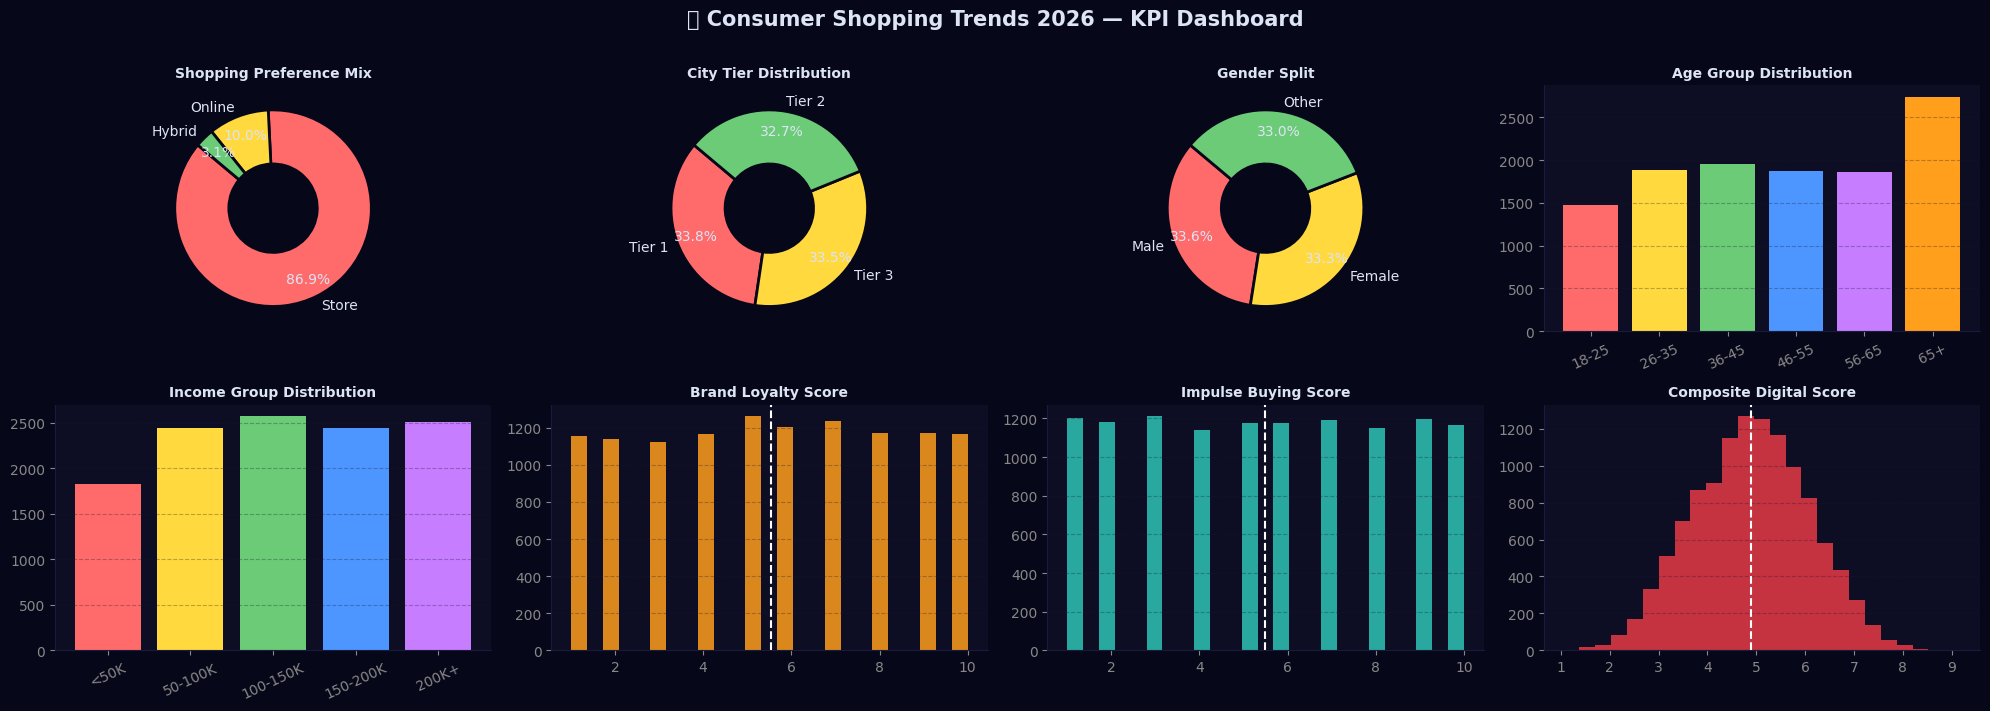

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 7))
kpi_charts = [
    ('shopping_preference', 'Shopping Preference Mix', 'pie'),
    ('city_tier',           'City Tier Distribution',  'pie'),
    ('gender',              'Gender Split',             'pie'),
    ('age_group',           'Age Group Distribution',   'bar'),
    ('income_group',        'Income Group Distribution','bar'),
    ('brand_loyalty_score', 'Brand Loyalty Score',      'hist'),
    ('impulse_buying_score','Impulse Buying Score',     'hist'),
    ('digital_score',       'Composite Digital Score',  'hist'),
]
for ax, (col, title, kind) in zip(axes.flat, kpi_charts):
    if kind == 'pie':
        vals = df[col].value_counts()
        ax.pie(vals.values, labels=vals.index, autopct='%1.1f%%',
               colors=PAL[:len(vals)], startangle=140,
               wedgeprops=dict(width=0.55, edgecolor=BG, linewidth=2), pctdistance=0.8)
    elif kind == 'bar':
        vals = df[col].value_counts().sort_index()
        ax.bar(vals.index.astype(str), vals.values, color=PAL[:len(vals)], edgecolor='none')
        ax.tick_params(axis='x', rotation=25); ax.grid(True, axis='y', alpha=0.3)
    else:
        idx = [c for c,_,_ in kpi_charts].index(col)
        ax.hist(df[col].dropna(), bins=25, color=PAL[idx % len(PAL)], edgecolor='none', alpha=0.85)
        ax.axvline(df[col].mean(), color='white', lw=1.5, ls='--'); ax.grid(True, axis='y', alpha=0.3)
    ax.set_title(title, fontsize=10, fontweight='bold')
plt.suptitle('🛒 Consumer Shopping Trends 2026 — KPI Dashboard', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

# 1. Configuration for the interactive dashboard
kpi_charts = [
    ('shopping_preference', 'Shopping Preference Mix', 'pie'),
    ('city_tier',           'City Tier Distribution',  'pie'),
    ('gender',              'Gender Split',             'pie'),
    ('age_group',           'Age Group Distribution',   'bar'),
    ('income_group',        'Income Group Distribution','bar'),
    ('brand_loyalty_score', 'Brand Loyalty Score',      'hist'),
    ('impulse_buying_score','Impulse Buying Score',     'hist'),
    ('digital_score',       'Composite Digital Score',  'hist'),
]

# 2. Initialize Subplots (2 rows, 4 columns)
# Specs define the type of chart for each cell (pie vs xy)
fig = make_subplots(
    rows=2, cols=4,
    subplot_titles=[title for _, title, _ in kpi_charts],
    specs=[[{"type": "pie"}, {"type": "pie"}, {"type": "pie"}, {"type": "xy"}],
           [{"type": "xy"}, {"type": "xy"}, {"type": "xy"}, {"type": "xy"}]],
    vertical_spacing=0.12,
    horizontal_spacing=0.07
)

# 3. Add traces dynamically
for i, (col, title, kind) in enumerate(kpi_charts):
    row = (i // 4) + 1
    col_pos = (i % 4) + 1

    if kind == 'pie':
        vals = df[col].value_counts()
        fig.add_trace(
            go.Pie(labels=vals.index, values=vals.values, hole=0.5,
                   textinfo='percent', hoverinfo='label+value+percent'),
            row=row, col=col_pos
        )

    elif kind == 'bar':
        vals = df[col].value_counts().sort_index()
        fig.add_trace(
            go.Bar(x=vals.index.astype(str), y=vals.values,
                   marker=dict(color=vals.values, colorscale='Viridis'),
                   showlegend=False),
            row=row, col=col_pos
        )

    else: # Histogram
        fig.add_trace(
            go.Histogram(x=df[col].dropna(), nbinsx=25,
                         marker=dict(line=dict(width=0.5, color='white')),
                         showlegend=False),
            row=row, col=col_pos
        )
        # Add a vertical line for the mean
        # Use add_shape with explicit xref/yref to avoid conflicts with pie subplots
        # The dashboard has 4 columns, which is explicitly set in make_subplots
        k_axis = (row - 1) * 4 + col_pos # Calculate the subplot's axis number
        xaxis_ref = 'x' if k_axis == 1 else f'x{k_axis}'
        yaxis_ref = 'y' if k_axis == 1 else f'y{k_axis}'

        fig.add_shape(
            type="line",
            x0=df[col].mean(),
            x1=df[col].mean(),
            y0=0,
            y1=1,
            xref=xaxis_ref,
            yref=yaxis_ref + ' domain',
            line=dict(dash="dash", color="red")
        )

# 4. Update Layout & Theme
fig.update_layout(
    height=800,
    width=1300,
    title_text="🛒 Consumer Shopping Trends 2026 — Interactive KPI Dashboard",
    template="plotly_white", # Change to "plotly_dark" if preferred
    showlegend=True
)

# Align the legend to the right
fig.update_layout(legend=dict(orientation="v", yanchor="middle", y=0.5, xanchor="left", x=1.02))

fig.show()

/usr/local/lib/python3.12/dist-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Setup the Subplots (1 Row, 3 Columns)
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=(
        'Age Distribution',
        'Monthly Income Distribution',
        'Avg Income by Age Group'
    ),
    horizontal_spacing=0.1
)

# --- Chart 1: Age Distribution (Histogram) ---
fig.add_trace(
    go.Histogram(
        x=df['age'],
        nbinsx=30,
        name='Age',
        marker_color='#4d96ff',
        opacity=0.85,
        hovertemplate='Age Range: %{x}<br>Count: %{y}<extra></extra>'
    ),
    row=1, col=1
)

# Add Mean/Median lines for Age
fig.add_vline(x=df['age'].mean(), line_dash="dash", line_color="#ffd93d",
              annotation_text=f"Mean: {df['age'].mean():.1f}", row=1, col=1)
fig.add_vline(x=df['age'].median(), line_dash="dot", line_color="#ff6b6b",
              annotation_text=f"Median: {df['age'].median():.1f}", row=1, col=1)

# --- Chart 2: Monthly Income Distribution (Histogram) ---
fig.add_trace(
    go.Histogram(
        x=df['monthly_income'],
        nbinsx=40,
        name='Income',
        marker_color='#6bcb77',
        opacity=0.85,
        hovertemplate='Income Range: ₹%{x}<br>Count: %{y}<extra></extra>'
    ),
    row=1, col=2
)

# Add Mean line for Income
fig.add_vline(x=df['monthly_income'].mean(), line_dash="dash", line_color="#ffd93d",
              annotation_text=f"Mean: ₹{df['monthly_income'].mean()/1000:.0f}K", row=1, col=2)

# --- Chart 3: Avg Income by Age Group (Bar) ---
age_income = df.groupby('age_group', observed=True)['monthly_income'].mean().reset_index()

fig.add_trace(
    go.Bar(
        x=age_income['age_group'].astype(str),
        y=age_income['monthly_income'],
        marker_color=['#4d96ff', '#6bcb77', '#ff6b6b', '#ffd93d', '#6c5ce7'], # Using PAL-like colors
        hovertemplate='Age Group: %{x}<br>Avg Income: ₹%{y:,.0f}<extra></extra>'
    ),
    row=1, col=3
)

# 2. Update Layout & Axis Formatting
fig.update_layout(
    height=500,
    width=1400,
    title_text="📊 Section 3 — Interactive Demographic Profile",
    template="plotly_white",
    showlegend=False
)

# Format currency on Y-axes
fig.update_yaxes(tickprefix="₹", tickformat=".0s", row=1, col=2)
fig.update_yaxes(tickprefix="₹", tickformat=".0s", row=1, col=3)

# Add a range slider to the Income chart for better inspection
fig.update_xaxes(rangeslider=dict(visible=True), row=1, col=2)

fig.show()

/tmp/ipykernel_9903/1543180511.py:16: UserWarning:

Glyph 128187 (\N{PERSONAL COMPUTER}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128187 (\N{PERSONAL COMPUTER}) missing from font(s) DejaVu Sans.



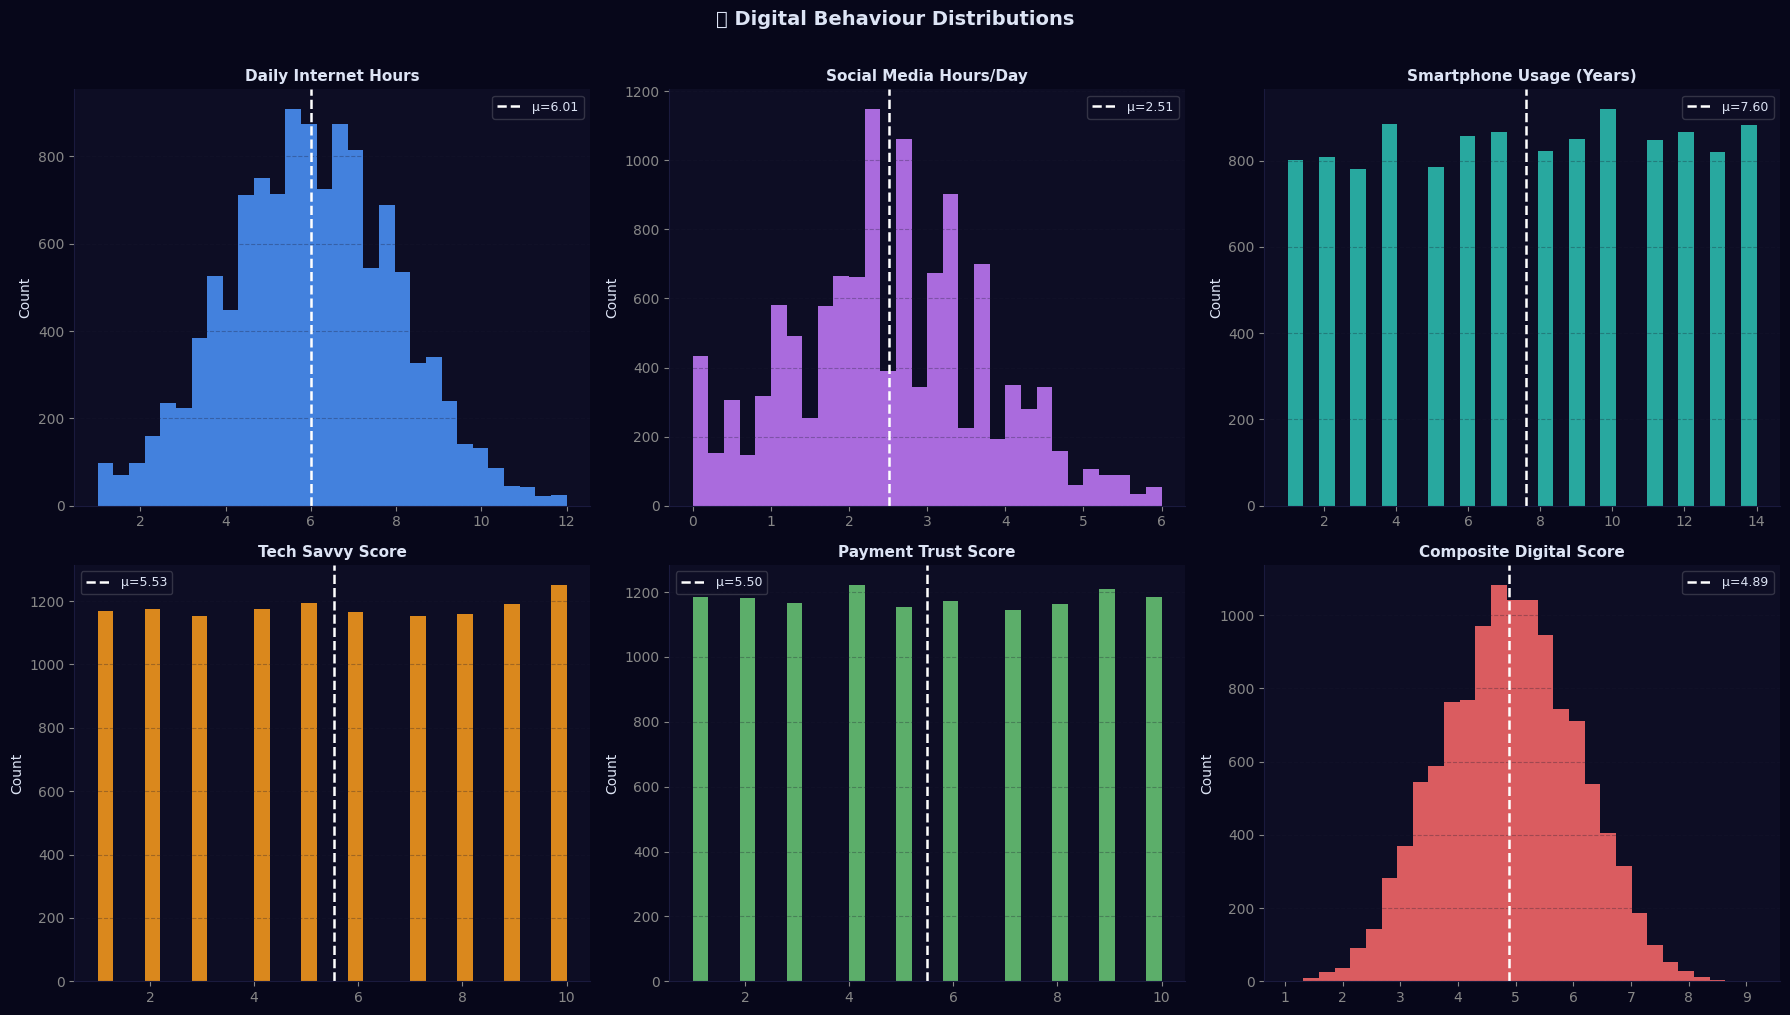

In [ ]:
digital_pairs = [
    ('daily_internet_hours','Daily Internet Hours','#4d96ff'),
    ('social_media_hours','Social Media Hours/Day','#c77dff'),
    ('smartphone_usage_years','Smartphone Usage (Years)','#2ec4b6'),
    ('tech_savvy_score','Tech Savvy Score','#ff9f1c'),
    ('online_payment_trust_score','Payment Trust Score','#6bcb77'),
    ('digital_score','Composite Digital Score','#ff6b6b'),
]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, (col, label, color) in zip(axes.flat, digital_pairs):
    ax.hist(df[col].dropna(), bins=30, color=color, edgecolor='none', alpha=0.85)
    ax.axvline(df[col].mean(), color='white', lw=1.8, ls='--', label=f'μ={df[col].mean():.2f}')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylabel('Count'); ax.legend(fontsize=9, framealpha=0.2); ax.grid(True, axis='y', alpha=0.3)
plt.suptitle('💻 Digital Behaviour Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Define the pairs and their styling
digital_pairs = [
    ('daily_internet_hours',      'Daily Internet Hours',        '#4d96ff'),
    ('social_media_hours',        'Social Media Hours/Day',      '#c77dff'),
    ('smartphone_usage_years',    'Smartphone Usage (Years)',    '#2ec4b6'),
    ('tech_savvy_score',          'Tech Savvy Score',            '#ff9f1c'),
    ('online_payment_trust_score','Payment Trust Score',         '#6bcb77'),
    ('digital_score',             'Composite Digital Score',     '#ff6b6b'),
]

# 2. Initialize Subplots (2 rows, 3 columns)
fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=[label for _, label, _ in digital_pairs],
    vertical_spacing=0.12,
    horizontal_spacing=0.08
)

# 3. Add traces dynamically
for i, (col, label, color) in enumerate(digital_pairs):
    row = (i // 3) + 1
    col_pos = (i % 3) + 1

    # Calculate mean for the annotation
    mean_val = df[col].mean()

    # Add Histogram
    fig.add_trace(
        go.Histogram(
            x=df[col].dropna(),
            nbinsx=30,
            marker_color=color,
            opacity=0.85,
            name=label,
            hovertemplate=f'<b>{label}</b><br>Range: %{{x}}<br>Count: %{{y}}<extra></extra>'
        ),
        row=row, col=col_pos
    )

    # Add Vertical Line for Mean (μ)
    fig.add_vline(
        x=mean_val,
        line_dash="dash",
        line_color="white",
        line_width=2,
        annotation_text=f"μ={mean_val:.2f}",
        annotation_position="top right",
        row=row, col=col_pos
    )

# 4. Update Layout & Aesthetics
fig.update_layout(
    height=700,
    width=1200,
    title_text="💻 Digital Behaviour Distributions",
    template="plotly_white", # Or "plotly_dark"
    showlegend=False
)

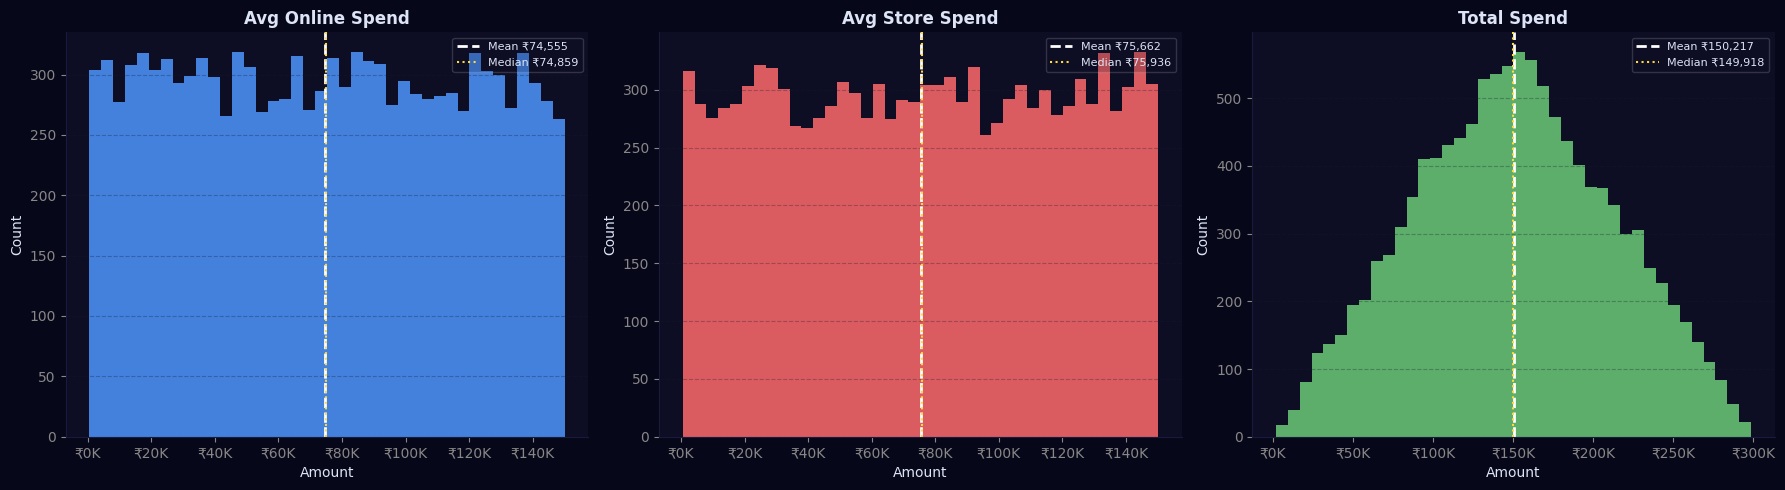

In [ ]:
import matplotlib.ticker as mtick

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, label, color in [
    (axes[0],'avg_online_spend','Avg Online Spend','#4d96ff'),
    (axes[1],'avg_store_spend','Avg Store Spend','#ff6b6b'),
    (axes[2],'total_spend','Total Spend','#6bcb77'),
]:
    ax.hist(df[col], bins=40, color=color, edgecolor='none', alpha=0.85)
    ax.axvline(df[col].mean(), color='white', lw=2, ls='--', label=f'Mean ₹{df[col].mean():,.0f}')
    ax.axvline(df[col].median(), color='#ffd93d', lw=1.5, ls=':', label=f'Median ₹{df[col].median():,.0f}')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Amount'); ax.set_ylabel('Count')
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'₹{x/1000:.0f}K'))
    ax.legend(fontsize=8, framealpha=0.2); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Setup the Subplots (1 Row, 3 Columns)
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=('Avg Online Spend', 'Avg Store Spend', 'Total Spend'),
    horizontal_spacing=0.08
)

# Configuration for the charts
spend_configs = [
    ('avg_online_spend', '#4d96ff'),
    ('avg_store_spend',  '#ff6b6b'),
    ('total_spend',      '#6bcb77')
]

# 2. Add traces dynamically
for i, (col, color) in enumerate(spend_configs):
    col_pos = i + 1

    # Histogram Trace
    fig.add_trace(
        go.Histogram(
            x=df[col],
            nbinsx=40,
            marker_color=color,
            opacity=0.85,
            name=col.replace('_', ' ').title(),
            hovertemplate='Spend: ₹%{x:,.0f}<br>Count: %{y}<extra></extra>'
        ),
        row=1, col=col_pos
    )

    # Add Mean line
    mean_val = df[col].mean()
    fig.add_vline(
        x=mean_val, line_dash="dash", line_color="white", line_width=2,
        annotation_text=f"Mean: ₹{mean_val/1000:.1f}K",
        annotation_position="top", row=1, col=col_pos
    )

    # Add Median line
    median_val = df[col].median()
    fig.add_vline(
        x=median_val, line_dash="dot", line_color="#ffd93d", line_width=1.5,
        annotation_text=f"Med: ₹{median_val/1000:.1f}K",
        annotation_position="bottom", row=1, col=col_pos
    )

# 3. Layout and Axis Formatting
fig.update_layout(
    height=500,
    width=1400,
    title_text="💰 Interactive Spending Distribution Analysis",
    template="plotly_white",
    showlegend=False,
    bargap=0.05
)

# Apply currency formatting to all x-axes
fig.update_xaxes(tickprefix="₹", tickformat=".2s", title_text="Amount")
fig.update_yaxes(title_text="Count", row=1, col=1)

fig.show()

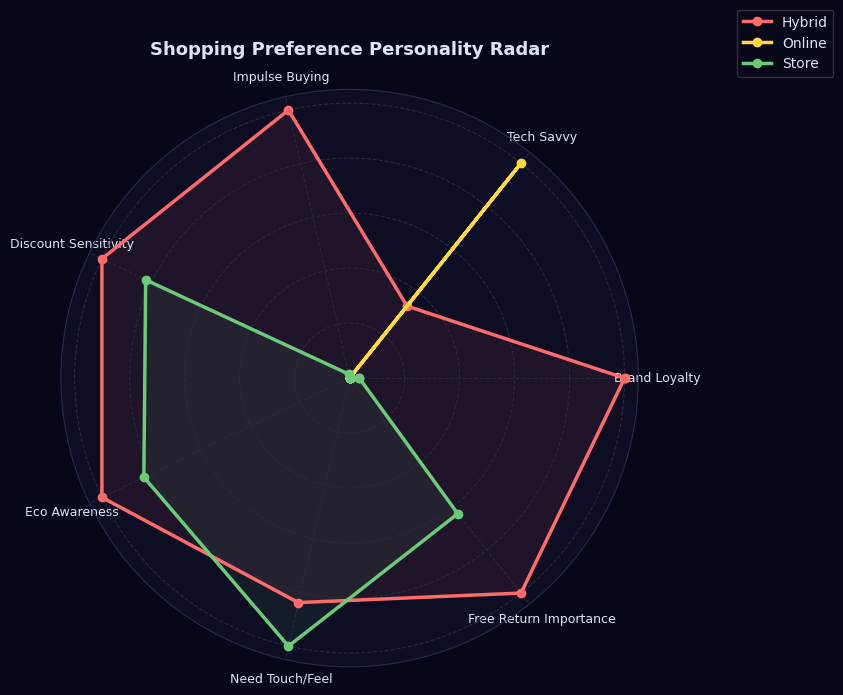

In [ ]:
radar_cols = ['brand_loyalty_score','tech_savvy_score','impulse_buying_score',
              'discount_sensitivity','environmental_awareness',
              'need_touch_feel_score','free_return_importance']
radar_labels = ['Brand Loyalty','Tech Savvy','Impulse Buying','Discount Sensitivity',
                'Eco Awareness','Need Touch/Feel','Free Return Importance']

pref_radar = df.groupby('shopping_preference')[radar_cols].mean()
pref_radar_n = (pref_radar - pref_radar.min()) / (pref_radar.max() - pref_radar.min())

N = len(radar_cols)
angles = [n/float(N)*2*pi for n in range(N)] + [0]

fig, ax = plt.subplots(figsize=(9, 7), subplot_kw=dict(polar=True))
ax.set_facecolor(AX_BG); fig.patch.set_facecolor(BG)

for i, pref in enumerate(pref_radar_n.index.tolist()):
    vals = pref_radar_n.loc[pref].tolist() + [pref_radar_n.loc[pref].tolist()[0]]
    ax.plot(angles, vals, 'o-', lw=2.5, color=PAL[i], label=pref)
    ax.fill(angles, vals, alpha=0.08, color=PAL[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, color=TEXT_C, fontsize=9)
ax.set_yticklabels([])
ax.set_title('Shopping Preference Personality Radar', fontsize=13, fontweight='bold', color=TEXT_C, pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), framealpha=0.2, fontsize=10)
ax.spines['polar'].set_color('#2a2a4e'); ax.grid(color='#2a2a3e')
plt.tight_layout(); plt.show()

In [ ]:
melt_cols = ['brand_loyalty_score','impulse_buying_score',
             'environmental_awareness','discount_sensitivity']
melt_df = df[melt_cols + ['city_tier']].melt(id_vars='city_tier',
    var_name='Score_Type', value_name='Score')
fig = px.box(
    melt_df, x='Score_Type', y='Score', color='city_tier',
    color_discrete_sequence=PAL,
    title='📦 Key Behavioural Scores by City Tier',
    labels={'Score_Type':'Score','Score':'Score (0-10)'},
    template=PT, height=460
)
fig.show()


In [ ]:
ct_pref = df.groupby(['city_tier','shopping_preference']).size().reset_index(name='count')
ct_pref['pct'] = ct_pref['count'] / ct_pref.groupby('city_tier')['count'].transform('sum') * 100

fig = make_subplots(rows=1, cols=2,
    subplot_titles=('Shopping Preference Mix by City Tier (%)','Avg Spend (Online vs Store) by City Tier'))
for i, pref in enumerate(df['shopping_preference'].unique()):
    sub = ct_pref[ct_pref['shopping_preference']==pref]
    fig.add_trace(go.Bar(name=pref, x=sub['city_tier'], y=sub['pct'], marker_color=PAL[i]), row=1, col=1)

# Fix: Define 'city_spend' DataFrame
city_spend = df.groupby('city_tier')[['avg_online_spend', 'avg_store_spend']].mean().reset_index()

for col_name, color in [('avg_online_spend','#4d96ff'),('avg_store_spend','#ff6b6b')]:
    fig.add_trace(go.Bar(name=col_name.replace('_',' ').title(), x=city_spend['city_tier'], y=city_spend[col_name], marker_color=color), row=1, col=2)
fig.update_layout(title='🏙️ City Tier Shopping Patterns', template=PT, height=440,
                  barmode='stack', legend=dict(bgcolor='rgba(0,0,0,0.4)'))
fig.update_yaxes(ticksuffix='%', row=1, col=1)
fig.show()

In [ ]:
import plotly.graph_objects as go

# The 'city_spend' DataFrame was already created in a previous step
# city_spend = df.groupby('city_tier')[['avg_online_spend', 'avg_store_spend']].mean().reset_index()

fig = go.Figure()

for col_name, color in [('avg_online_spend','#4d96ff'),('avg_store_spend','#ff6b6b')]:
    fig.add_trace(go.Bar(
        name=col_name.replace('_',' ').title(),
        x=city_spend['city_tier'],
        y=city_spend[col_name],
        marker_color=color,
        hovertemplate='City Tier: %{x}<br>Average Spend: ₹%{y:,.0f}<extra></extra>'
    ))

fig.update_layout(
    title='Average Spend (Online vs Store) by City Tier',
    template=PT,
    height=440,
    barmode='group', # Important for grouped bars
    legend=dict(bgcolor='rgba(0,0,0,0.4)', x=0.01, y=0.99), # Adjust legend position
    xaxis_title='City Tier',
    yaxis_title='Average Spend'
)
fig.update_yaxes(tickprefix='₹', tickformat='.0f') # Format y-axis as currency
fig.show()